# Sharp-Wave Detection in LFP
This notebook contains a SW detection code for LFP signals.

It uses the EC traces from our multi-modal recordings.

The EC signal has been filtered for LFP.

## Importing necessary libraries

In [2]:
import time
import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw

## Defining paths and importing files from disk

### Defining data paths

In [ ]:
# Recording paths
# SP1
sp1_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/spike_sorting_Thresh_9_9/Data/")
# SP6
sp6_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/")
# SP7
sp7_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/spike_sorting_Thresh_9_9/Data/")
# SP9
sp9_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/")

In [4]:
# Filtered LFP paths
filtered_lfp_paths = {
    "sp1_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_01/optimal",
    "sp1_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_02/optimal",
    "sp1_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp1_03/optimal",
    "sp6_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_01/optimal",
    "sp6_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_02/optimal",
    "sp6_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_03/optimal",
    "sp6_04": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp6_04/optimal",
    "sp7_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp7_01/optimal",
    "sp7_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp7_02/optimal",
    "sp9_01": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_01/optimal",
    "sp9_02": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_02/optimal",
    "sp9_03": "/Volumes/AFedor_T7/TTK-NeuroData/LFP codes/cached/own_data/sp9_03/optimal",
}

### Importing filtered LFP traces from disk

In [6]:
# Load the recordings from the cache to save time in case the notebook is re-run
recordings = dict()
for path in filtered_lfp_paths.keys():
    recording_name = path
    print(f"Loading recording: {recording_name}")
    recordings[recording_name] = si.load(filtered_lfp_paths[path])

Loading recording: sp1_01
Loading recording: sp1_02
Loading recording: sp1_03
Loading recording: sp6_01
Loading recording: sp6_02
Loading recording: sp6_03
Loading recording: sp6_04
Loading recording: sp7_01
Loading recording: sp7_02
Loading recording: sp9_01
Loading recording: sp9_02
Loading recording: sp9_03


In [8]:
n_ch = 32
for rec in recordings.keys():
    recordings[rec].set_property("gain_to_uV", [1.0] * n_ch)
    recordings[rec].set_property("offset_to_uV", [0.0] * n_ch)

### Checking the imports

Plotting a few LFP traces from a few files to see if the importing was a success and to visualize our data

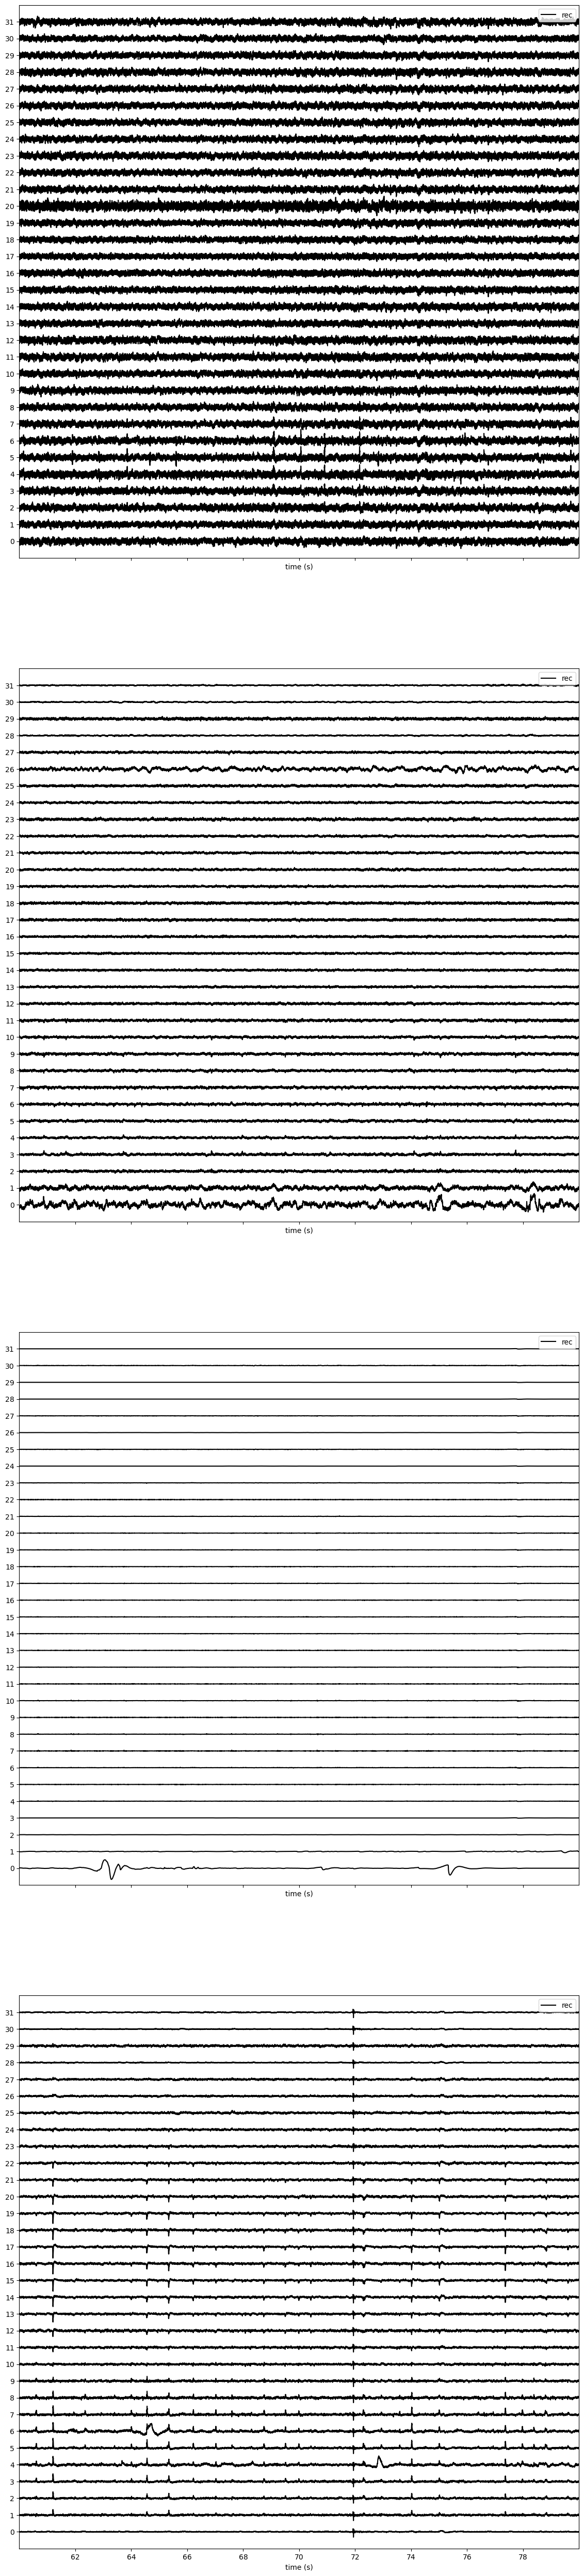

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(14, 64), sharex=True)
time_range = [60, 80]  # Time range in seconds for plotting

# GENERALLY TRUE: These figures show only the 6 channels that are thought to be closest to the soma OR show all channels. 
# The channels to plot can be changed by modifying the `spX_channels_to_plot` variables below.
# The channels' indexing goes from 0 to 31, where 0 is the first channel and 31 is the last channel.

# Plotting a small piece of a few channels of the SP1_01 recording
# sp1_channels_to_plot = np.arange(0, 6) # Plotting channels 0 to 5 for SP1_01 recording
sp1_channels_to_plot = None  # Plotting all channels for SP1_01 recording
sw.plot_traces(recordings["sp1_01"], ax=axs[0], show_channel_ids=True, channel_ids=sp1_channels_to_plot, time_range=time_range, return_in_uV=True)

# Plotting a small piece of a few channels of the SP6_01 recording
# sp6_channels_to_plot = np.arange(3, 9) # Plotting channels 3 to 8 for SP6_01 recording
sp6_channels_to_plot = None  # Plotting all channels for SP6_01 recording
sw.plot_traces(recordings["sp6_01"], ax=axs[1], show_channel_ids=True, channel_ids=sp6_channels_to_plot, time_range=time_range, return_in_uV=True)

# Plotting a small piece of a few channels of the SP7_01 recording
# sp7_channels_to_plot = np.arange(5, 11) # Plotting channels 5 to 10 for SP7_01 recording
sp7_channels_to_plot = None  # Plotting all channels for SP7_01 recording
sw.plot_traces(recordings["sp7_01"], ax=axs[2], show_channel_ids=True, channel_ids=sp7_channels_to_plot, time_range=time_range, return_in_uV=True)

# Plotting a small piece of a few channels of the SP9_01 recording
# sp9_channels_to_plot = np.arange(4, 9) # Plotting channels 4 to 8 for SP9_01 recording
sp9_channels_to_plot = None  # Plotting all channels for SP9_01 recording
sw.plot_traces(recordings["sp9_01"], ax=axs[3], show_channel_ids=True, channel_ids=sp9_channels_to_plot, time_range=time_range, return_in_uV=True)

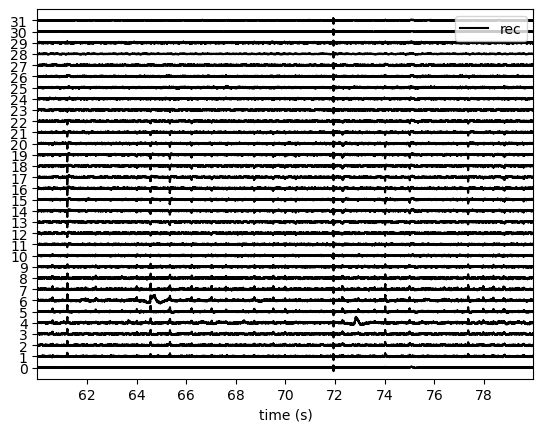

In [22]:
_ = sw.plot_traces(recordings["sp9_01"], show_channel_ids=True, time_range=time_range, return_in_uV=True)